In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage import io, color
import time
import os
import random

In [51]:
data = loadmat('/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/drishtant/data/learned_dictionary_bsds500.mat')
D = data['D_learned']

# Normalize dictionary
D = D / np.linalg.norm(D, axis=0, keepdims=True)

print("Dictionary shape:", D.shape)

Dictionary shape: (64, 256)


In [52]:
def load_image(path):
    img = io.imread(path)

    if len(img.shape) == 3:
        img = color.rgb2gray(img)

    img = img.astype(np.float32)

    # Safe normalization
    if img.max() > 1:
        img = img / 255.0
    else:
        img = img / img.max()

    return img

In [53]:
def add_noise(img, sigma=0.1):
    noisy = img + sigma * np.random.randn(*img.shape)
    return np.clip(noisy, 0, 1)

In [54]:
def extract_patches_with_mean(img, patch_size=8):
    patches = []
    means = []

    h, w = img.shape

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            m = np.mean(patch)

            patches.append((patch - m).flatten())
            means.append(m)

    return np.array(patches), np.array(means)

In [55]:
def reconstruct_image_with_mean(patches, means, img_shape, patch_size=8):
    h, w = img_shape
    img = np.zeros(img_shape)
    idx = 0

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = patches[idx].reshape(patch_size, patch_size)
            img[i:i+patch_size, j:j+patch_size] = patch + means[idx]
            idx += 1

    return img

In [56]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2)**2)
    return 10 * np.log10(1.0 / mse)

def rmse(img1, img2):
    return np.sqrt(np.mean((img1 - img2)**2))

In [57]:
def soft_threshold(x, thresh):
    return np.sign(x) * np.maximum(np.abs(x) - thresh, 0)

In [58]:
def ista(D, y, lam=0.1, max_iter=5):

    x = np.zeros(D.shape[1])

    # Lipschitz constant
    L = np.linalg.norm(D, ord=2)**2
    t = 1.0 / L

    for _ in range(max_iter):
        grad = D.T @ (D @ x - y)
        x = soft_threshold(x - t * grad, lam * t)

    return x

In [59]:
def ista_denoise(img, D, sigma=0.1, lam=0.25):

    noisy = add_noise(img, sigma)

    patches, means = extract_patches_with_mean(noisy)

    start = time.time()

    X = []
    for p in patches:
        X.append(ista(D, p, lam=lam, max_iter=5))

    X = np.array(X)

    reconstructed = np.dot(X, D.T)

    denoised = reconstruct_image_with_mean(reconstructed, means, img.shape)

    elapsed = time.time() - start

    return noisy, denoised, elapsed

In [60]:
img_path = '/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/datasets/BSDS500/images/test/130014.jpg'  # or giraffe

img = load_image(img_path)

noisy, denoised, t = ista_denoise(img, D)

print("PSNR:", psnr(img, denoised))
print("RMSE:", rmse(img, denoised))
print("Time:", t)

PSNR: 23.75485253401329
RMSE: 0.06490189437541616
Time: 121.87409806251526


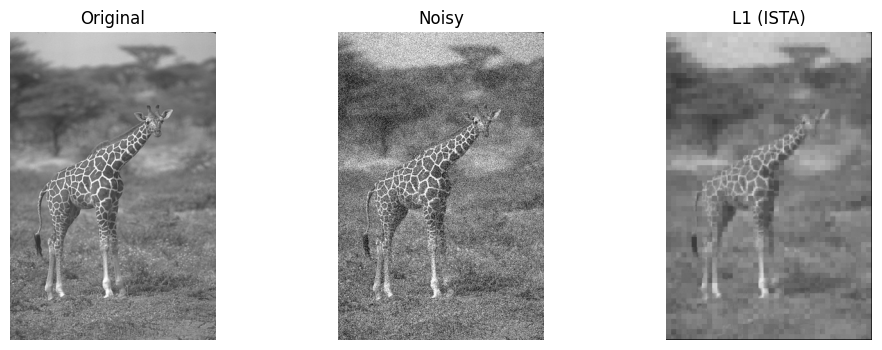

In [61]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray', vmin=0, vmax=1)
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray', vmin=0, vmax=1)
plt.title("L1 (ISTA)")
plt.axis('off')

plt.show()

In [62]:
dataset_path = "/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/datasets/BSDS500/images/test"

image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith('.jpg')]

random.shuffle(image_files)
selected_images = image_files[:20]

In [63]:
psnr_list = []
rmse_list = []
time_list = []

for img_path in selected_images:

    img = load_image(img_path)

    noisy, denoised, t = ista_denoise(img, D)

    psnr_list.append(psnr(img, denoised))
    rmse_list.append(rmse(img, denoised))
    time_list.append(t)

    print(f"{os.path.basename(img_path)} → PSNR: {psnr_list[-1]:.2f}")

223004.jpg → PSNR: 23.62
134067.jpg → PSNR: 18.70
8068.jpg → PSNR: 25.58
104055.jpg → PSNR: 27.54
117025.jpg → PSNR: 21.69
163004.jpg → PSNR: 22.99
35028.jpg → PSNR: 26.75
70090.jpg → PSNR: 24.49
100007.jpg → PSNR: 24.65
108036.jpg → PSNR: 21.29
107072.jpg → PSNR: 21.72
120093.jpg → PSNR: 20.62
188025.jpg → PSNR: 22.17
346016.jpg → PSNR: 20.47
128035.jpg → PSNR: 25.60
175083.jpg → PSNR: 22.32
118031.jpg → PSNR: 22.09
235098.jpg → PSNR: 21.96
196027.jpg → PSNR: 25.36
97010.jpg → PSNR: 19.85


In [64]:
print("\n===== L1 FINAL RESULTS =====")
print("Average PSNR:", np.mean(psnr_list))
print("Average RMSE:", np.mean(rmse_list))
print("Average Time:", np.mean(time_list))


===== L1 FINAL RESULTS =====
Average PSNR: 22.9734330046101
Average RMSE: 0.073551549713643
Average Time: 117.10136187076569
